In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import os
import shutil
from pathlib import Path
import seaborn as sns 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for machine learning tasks
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# XGBoost for advanced gradient boosting
import xgboost as xgb

# Scikit-learn pipelines and transformers for robust workflow
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

In [3]:
# зафиксируем условия работы генератора случайных чисел для воспроизводимости процессов
seed = 1234
np.random.seed(seed)

In [4]:
import kagglehub


# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
new_file = os.path.join(path, os.listdir(path)[0])

In [5]:
data_path = os.path.join(str(Path.home()), 'PycharmProjects/ML/src/data', 'credit-card-fraud')
if not os.path.exists(data_path):
    os.makedirs(data_path)

In [6]:
# перенесём файл в локальное рабочее пространство
shutil.copy(new_file, data_path)
train_path = os.path.join(data_path, os.listdir(data_path)[0])

In [7]:
df = pd.read_csv(train_path)
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


Проверим распределение данных

In [8]:
print(df['Class'].value_counts())
print(round(df['Class'].value_counts()[1]*100/df['Class'].value_counts()[0],4), "%")

Class
0    284315
1       492
Name: count, dtype: int64
0.173 %


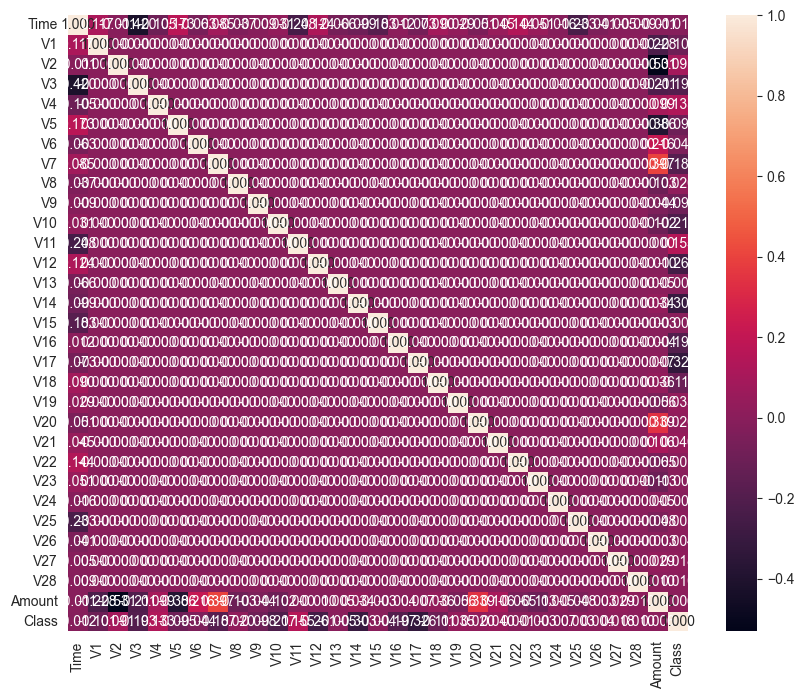

In [9]:
columns = df.select_dtypes(include = ['int', 'float'])
plt.figure(figsize = (10,8))
sns.heatmap(columns.corr(), annot=True, fmt='.3f')
plt.show()

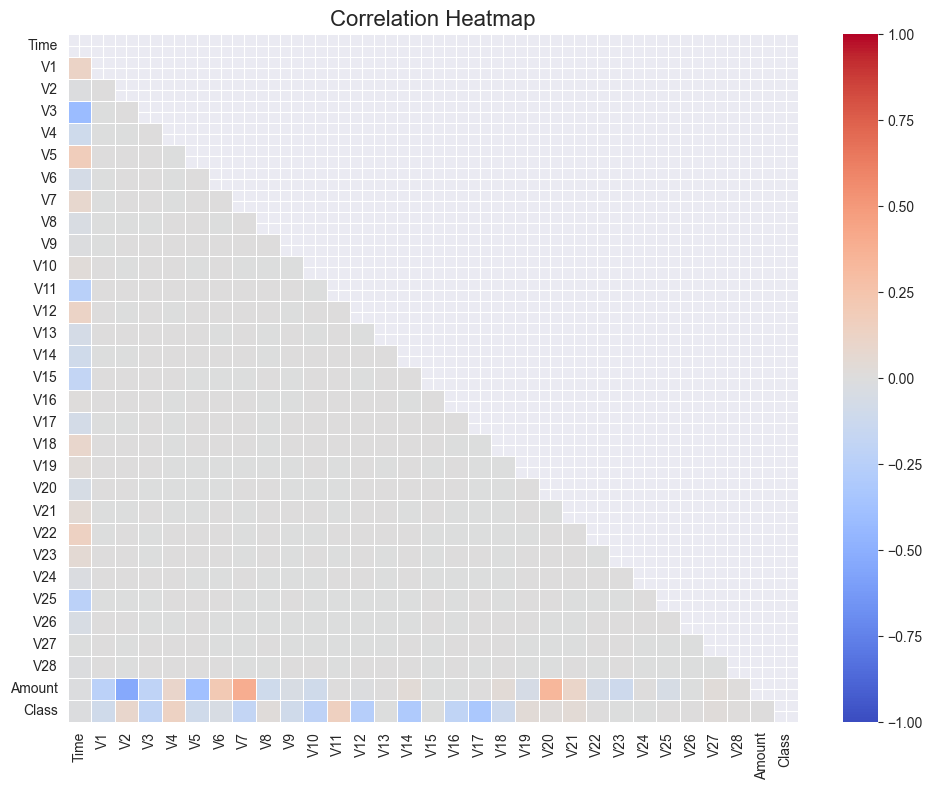


Top 10 Features Correlated with Class:
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64


In [10]:
# Корреляционная матрица признаков
plt.figure(figsize=(10, 8))
correlation = df.corr()
mask = np.triu(correlation)
sns.heatmap(correlation, annot=False, cmap='coolwarm', mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# Топ 10 признаков, коррелирующих с классом
class_corr = correlation['Class'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with Class:")
print(class_corr[1:11])  # Exclude Class itself

In [11]:
X = df.drop('Class', axis=1)
y = df['Class']

In [12]:
X['Amount'].head

<bound method NDFrame.head of 0         149.62
1           2.69
2         378.66
3         123.50
4          69.99
           ...  
284802      0.77
284803     24.79
284804     67.88
284805     10.00
284806    217.00
Name: Amount, Length: 284807, dtype: float64>

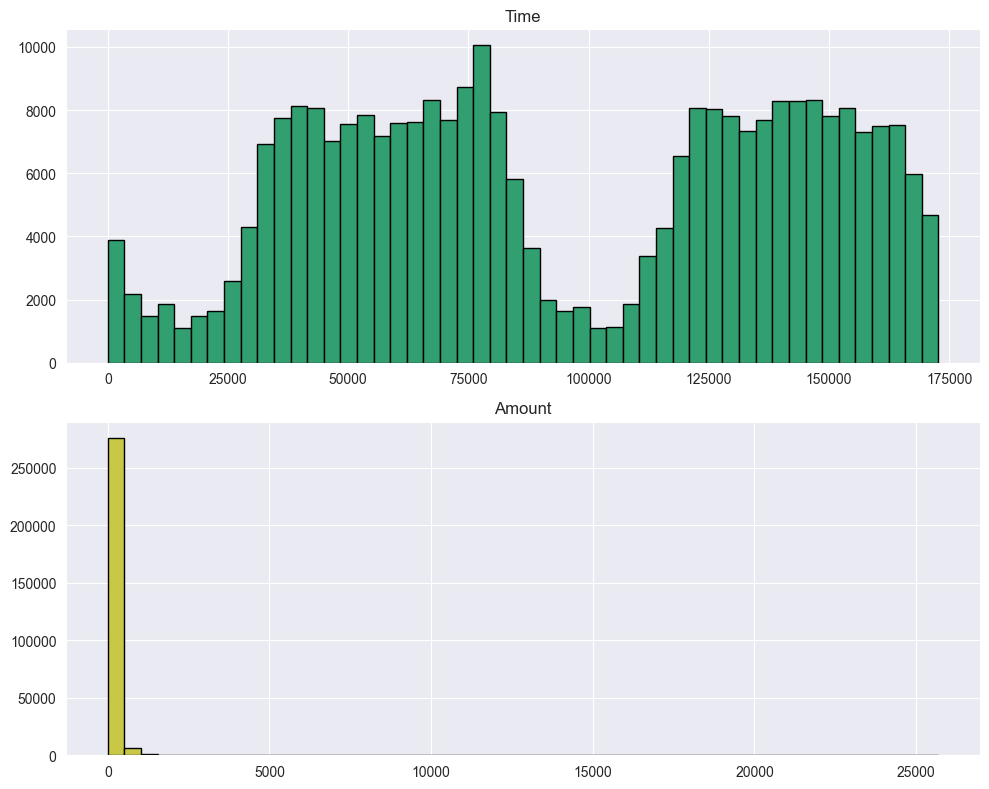

In [13]:
time_amount_columns = ['Time', 'Amount']
time_amount = df[time_amount_columns]


plt.figure(figsize=(10, 8))

np.random.seed(seed)
for idx, numeric in enumerate(time_amount_columns) :
    col = (np.random.random(), np.random.random(), np.random.random())

    plt.subplot(2, 1, idx+1)
    plt.hist(time_amount[numeric], bins=50, color=col, edgecolor='black')
    plt.title(numeric)
    plt.tight_layout()

plt.tight_layout()
plt.show()

In [25]:
Vs_columns = ['V1',  'V2',  'V3',  'V4',  'V5',  'V6',  'V7',  'V8',  'V9',  'V10',
              'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
              'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Vs_data = df[Vs_columns]

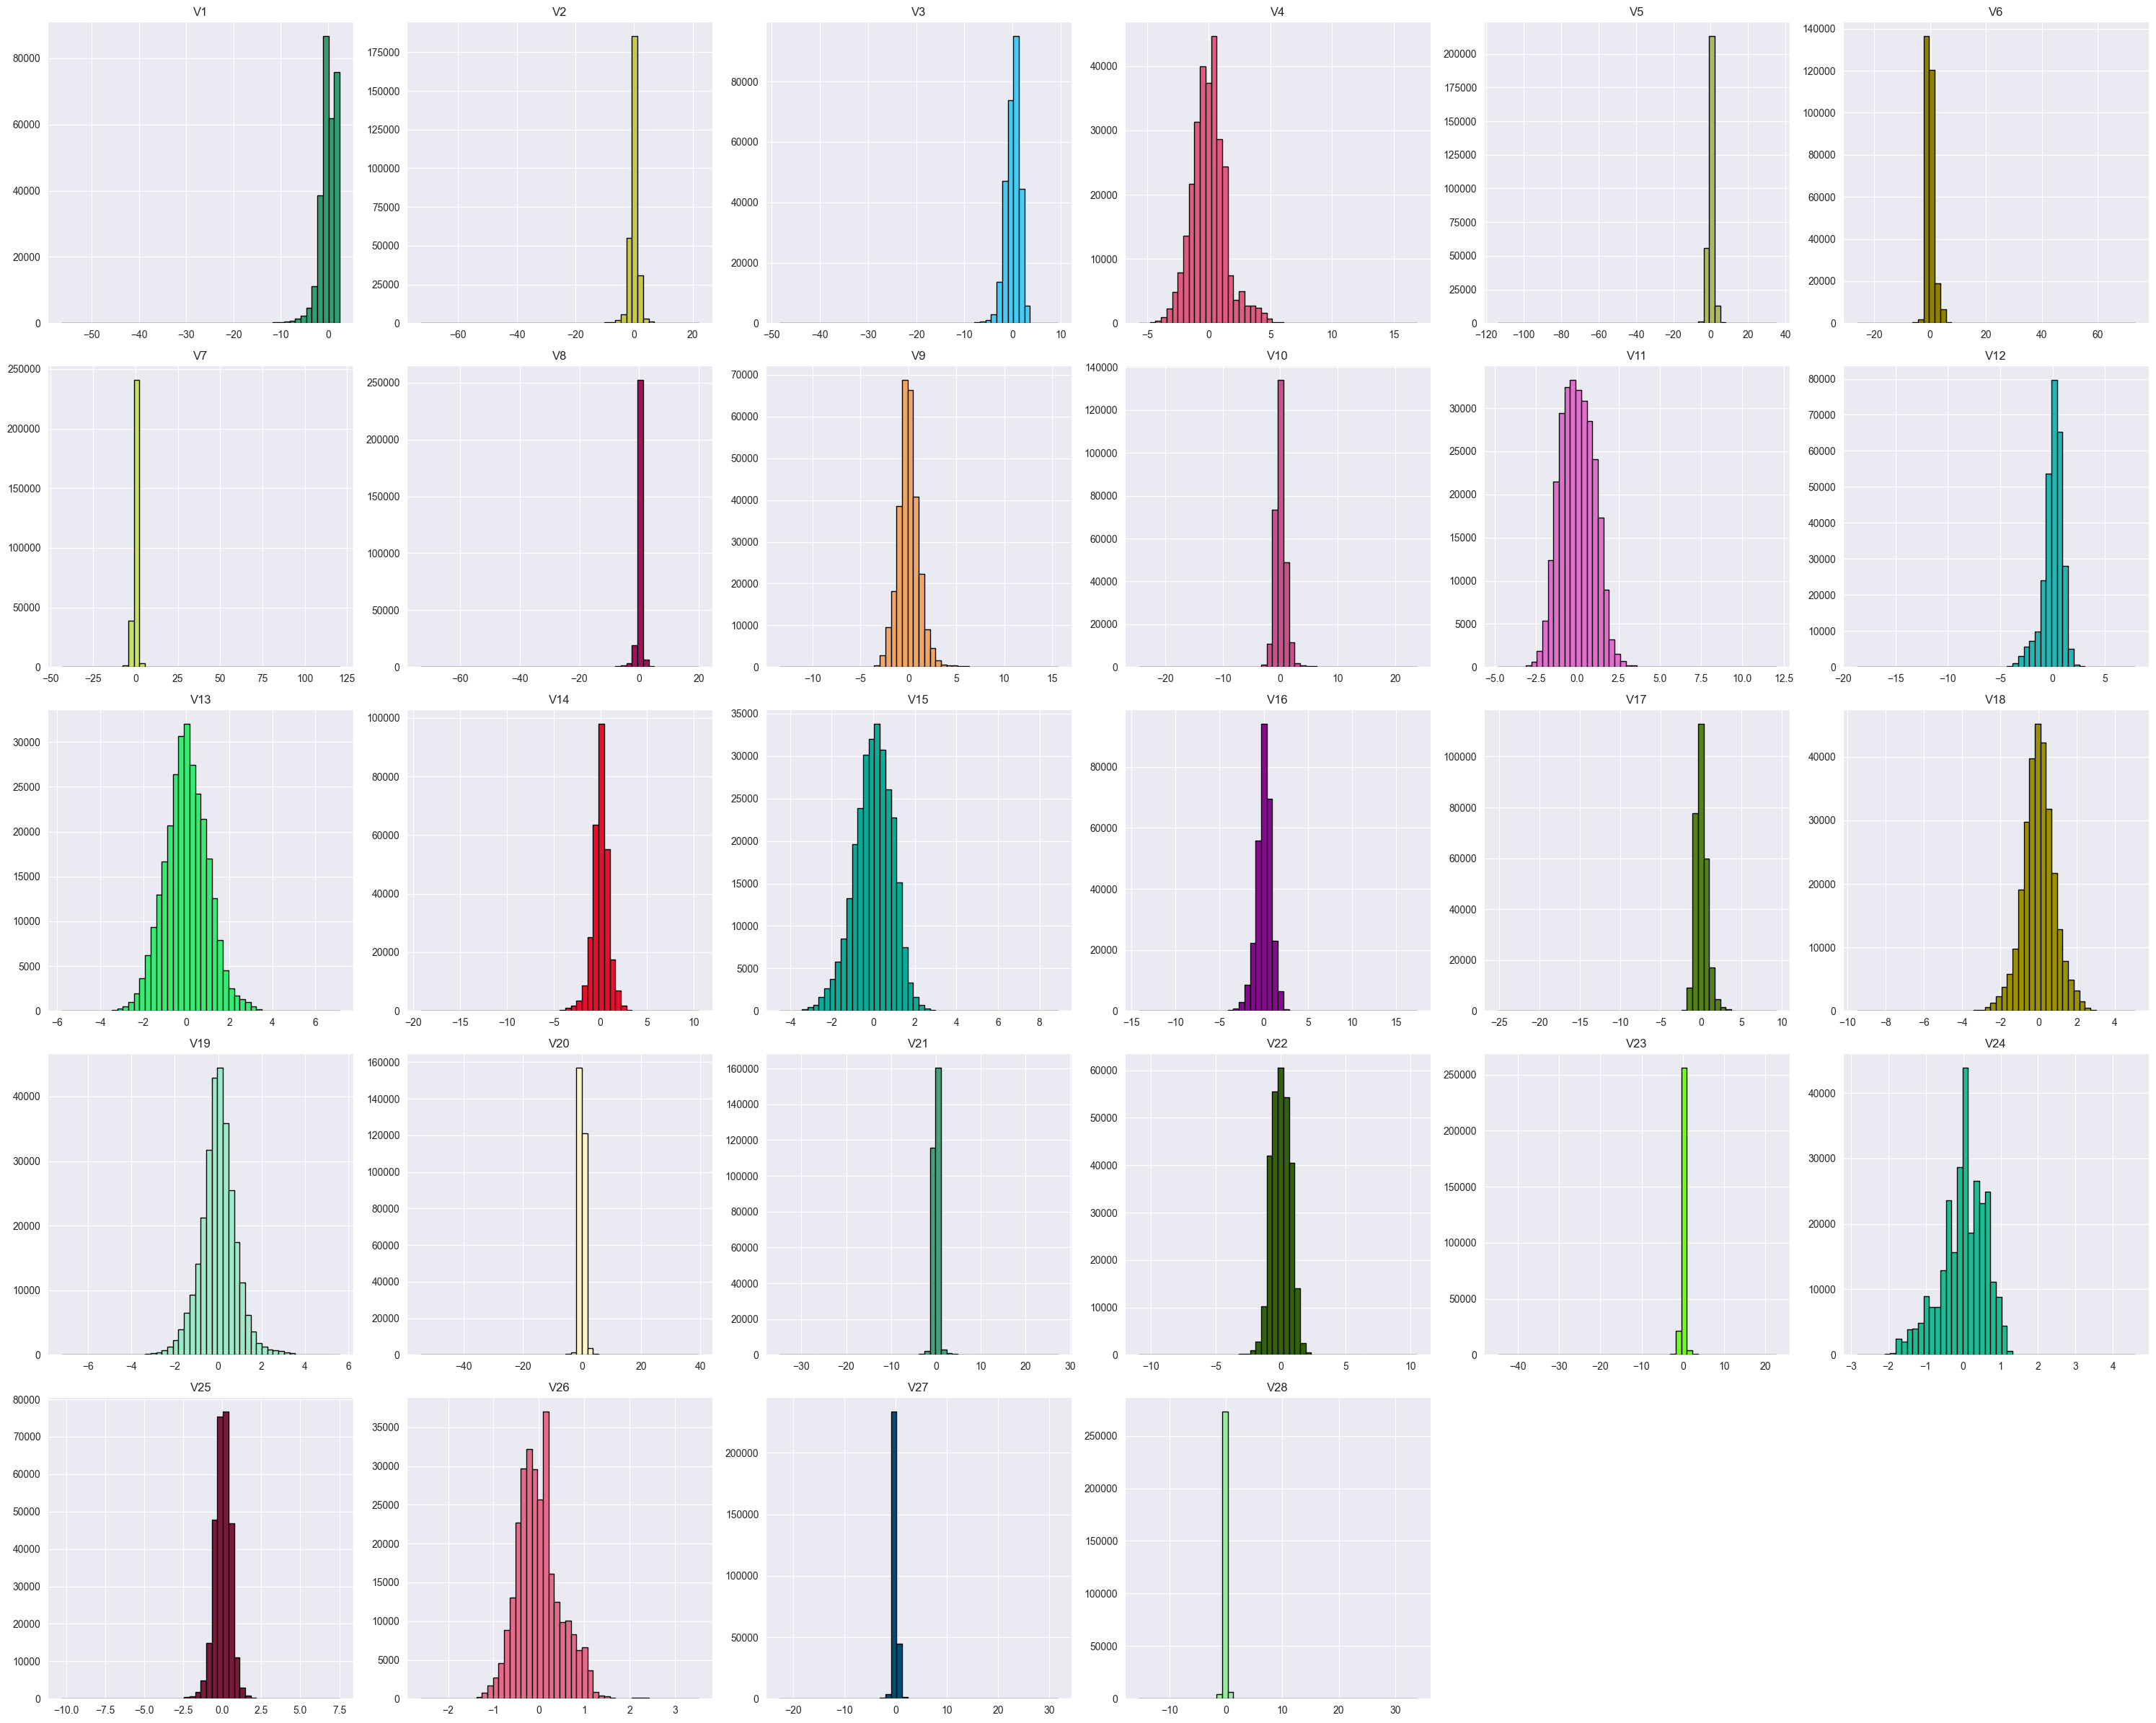

In [27]:
plt.figure(figsize=(30, 24))

np.random.seed(seed)
for idx, numeric in enumerate(Vs_columns) :
    col = (np.random.random(), np.random.random(), np.random.random())

    plt.subplot(5, 6, idx+1)
    plt.hist(Vs_data[numeric], bins=50, color=col, edgecolor='black')
    plt.title(numeric)
    plt.tight_layout()

plt.tight_layout()
plt.show()


--- 2.5 Распределение выбранных анонимизированных V-признаков по классам ---


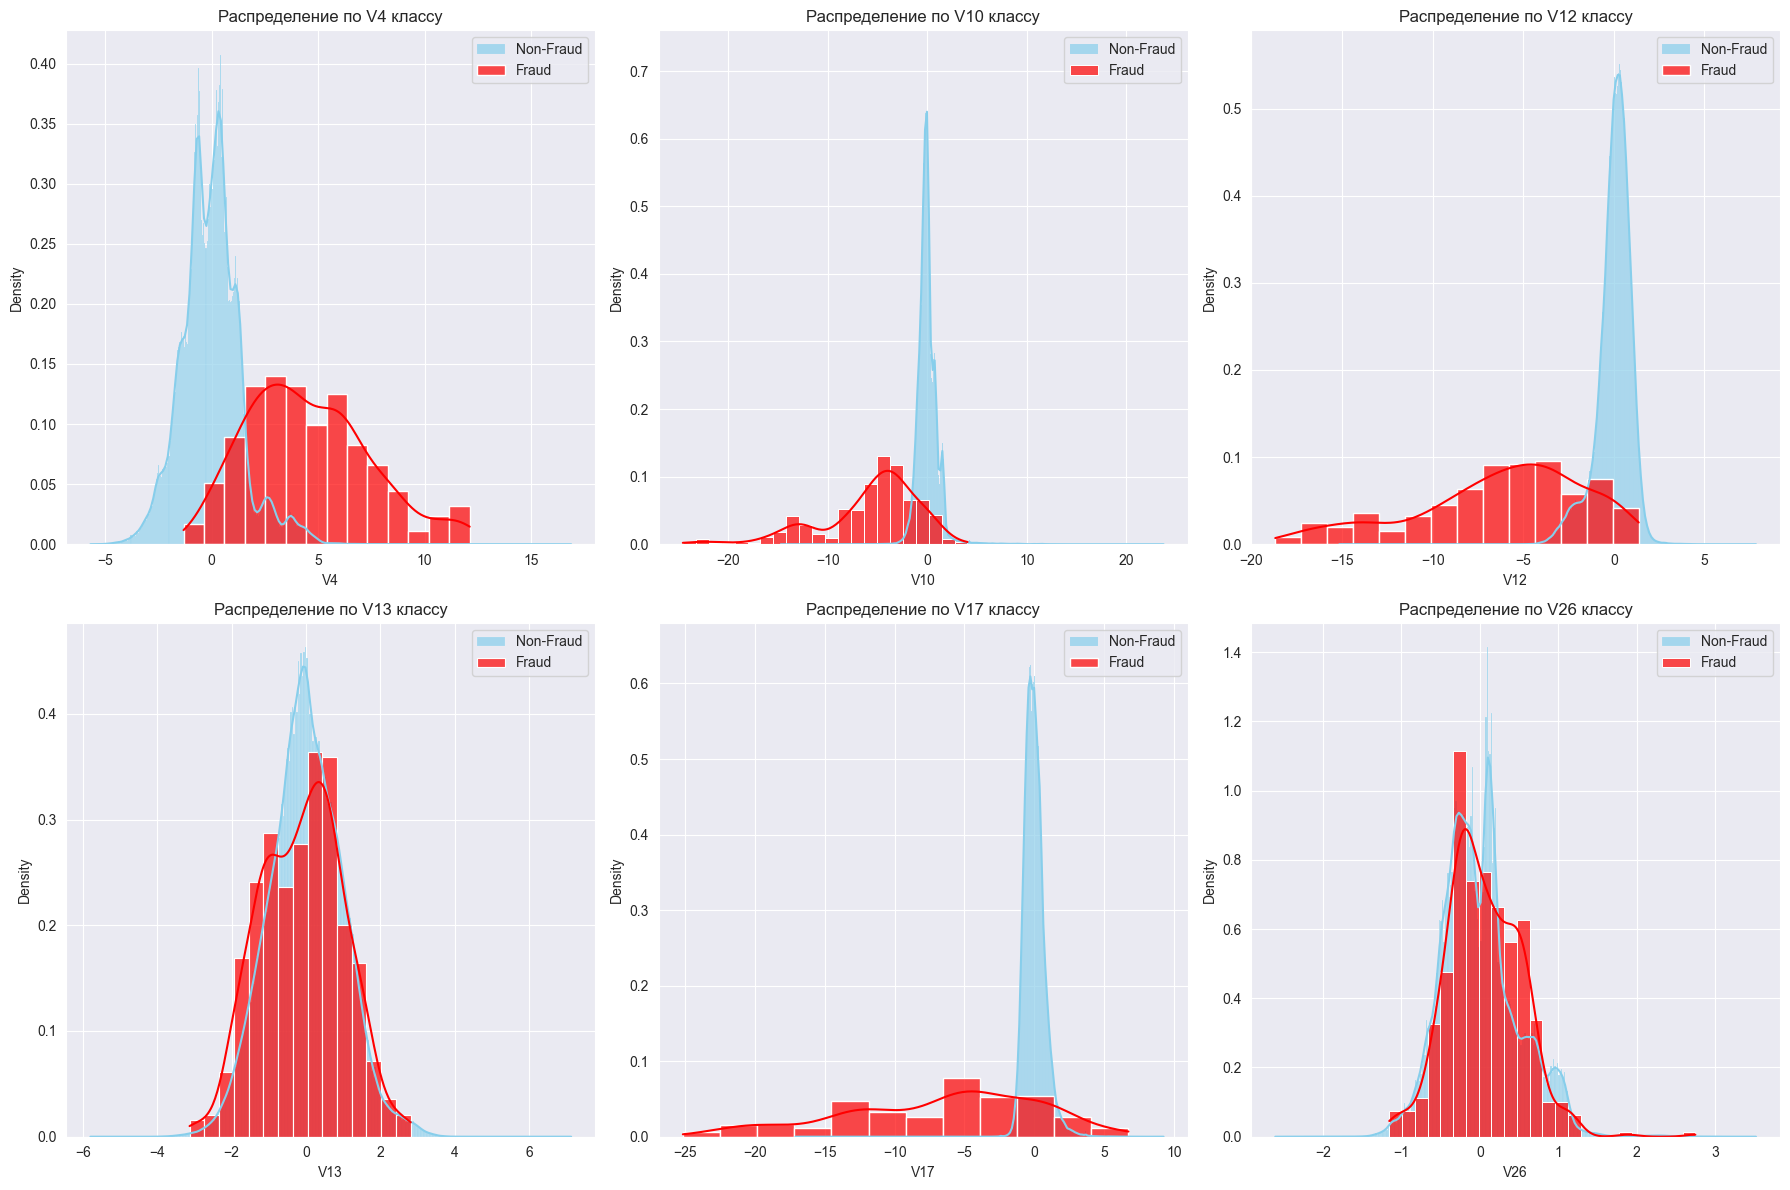

In [34]:
# 2.5 Распределение выбранных V-элементов по классам (визуализация разделения)
print("\n--- 2.5 Распределение выбранных анонимизированных V-признаков по классам ---")
# Выбор: подмножество V-признаков, которые часто являются высокодискриминационными с точки зрения мошенничества
v_features_to_plot = ['V4', 'V10', 'V12', 'V13', 'V17', 'V26']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(v_features_to_plot):
    plt.subplot(2, 3, i + 1) # Расположим графики в виде сетки 2x3
    sns.histplot(df[df['Class'] == 0][feature], kde=True, color='skyblue', label='Non-Fraud', stat='density', alpha=0.7)
    sns.histplot(df[df['Class'] == 1][feature], kde=True, color='red', label='Fraud', stat='density', alpha=0.7)
    plt.title(f'Распределение по {feature} классу')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
plt.tight_layout()
plt.show()

In [35]:
print("\n--- 3.1 Разделение признаков (X) и целевой переменной (y) ---")

# Признаки (X) - это все столбцы, кроме "Class"
X = df.drop('Class', axis=1)

# Цель (y) — столбец «Класс»
y = df['Class']

print(f"Форма признаков Х: {X.shape}")
print(f"Форма целевой переменной У: {y.shape}")
print("\nПервые 5 строк X:")
print(X.head())
print("\nПервые 5 значений y:")
print(y.head())


--- 3.1 Разделение признаков (X) и целевой переменной (y) ---
Форма признаков Х: (284807, 30)
Форма целевой переменной У: (284807,)

Первые 5 строк X:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.1

In [16]:
print("\n--- 3.2 Define Features for Scaling ---")

# Определим числовые признаки, требующие масштабирования
# "Время" и "Количество" - это необработанные числовые признаки, которые нуждаются в стандартизации.

numerical_features_to_scale = ['Time', 'Amount']

# Функции "V" (V1-V28) уже преобразованы в PCA и эффективно масштабируются.
# Мы пропустим их без дальнейших преобразований.

features_not_to_scale = [col for col in X.columns if col.startswith('V')]

print(f"Features to scale: {numerical_features_to_scale}")
print(f"Features not to scale (PCA-transformed): {features_not_to_scale[:5]} ... {features_not_to_scale[-5:]}") # Показать первый/последний несколько V-образных элементов


--- 3.2 Define Features for Scaling ---
Features to scale: ['Time', 'Amount']
Features not to scale (PCA-transformed): ['V1', 'V2', 'V3', 'V4', 'V5'] ... ['V24', 'V25', 'V26', 'V27', 'V28']


In [36]:
print("\n--- 3.3 Создание конвейера предварительной обработки с помощью ColumnTransformer ---")

# Создайте ColumnTransformer для применения StandardScaler только к указанным числовым признакам.
# "num_scaler": Название этого трансформатора.
# StandardScaler(): Применяемый трансформатор (стандартизирует функции, удаляя среднее значение и масштабируя до единичной дисперсии).
# numerical_features_to_scale: Список столбцов, к которым будет применен этот трансформер.
# remainder="passthrough": Это очень важно! Это гарантирует, что все остальные столбцы (V-функции) будут включены в выходные данные без какого-либо преобразования.

preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), numerical_features_to_scale)
    ],
    remainder='passthrough'
)

print("\nСоздан ColumnTransformer. Он применит StandardScaler к 'Времени' и 'Количеству' и пройдет через другие функции..")


--- 3.3 Создание конвейера предварительной обработки с помощью ColumnTransformer ---

Создан ColumnTransformer. Он применит StandardScaler к 'Времени' и 'Количеству' и пройдет через другие функции..


In [20]:
print("\n--- 3.4 Train-Test Split with Stratification ---")

# Инициализируйте StratifiedKFold для перекрестной проверки во время GridSearchCV.
# n_splits=5: Мы будем использовать 5 кратов для перекрестной проверки.
# shuffle=True: Перетасовывает данные перед разделением, что важно для случайности.
# random_state=42: Обеспечивает воспроизводимость разделений.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("StratifiedKFold (5-fold) initialized for robust cross-validation.")

# Выполните разделение обучения-теста для окончательной оценки модели.
# test_size=0.2: 20% данных будет использовано для тестирования, 80% — для обучения.
# random_state=42: Обеспечивает воспроизводимость разделения.
# stratify=y: ЭТО ВАЖНО! Это гарантирует, что доля мошеннических (класс 1) и немошеннических транзакций (класс 0)
# одинакова как в обучающем, так и в тестовом наборах, как и в исходном наборе данных.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set features (X_train) shape: {X_train.shape}")
print(f"Training set target (y_train) shape: {y_train.shape}")
print(f"Test set features (X_test) shape: {X_test.shape}")
print(f"Test set target (y_test) shape: {y_test.shape}")

# Проверка распределения классов в разбиениях
print("\nClass distribution in Training set:")
print(y_train.value_counts(normalize=True))
print("Class distribution in Test set:")
print(y_test.value_counts(normalize=True))

# подтвердить, что количество случаев мошенничества постоянно
print(f"\nFraudulent cases in Training set: {y_train.sum()}")
print(f"Fraudulent cases in Test set: {y_test.sum()}")


--- 3.4 Train-Test Split with Stratification ---
StratifiedKFold (5-fold) initialized for robust cross-validation.

Training set features (X_train) shape: (227845, 30)
Training set target (y_train) shape: (227845,)
Test set features (X_test) shape: (56962, 30)
Test set target (y_test) shape: (56962,)

Class distribution in Training set:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Class distribution in Test set:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64

Fraudulent cases in Training set: 394
Fraudulent cases in Test set: 98


In [21]:
print("\n--- 4.1 Определение моделей и сеток гиперпараметров ---")

# --- Определяем модель ---
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss',
                                 # cale_pos_weight — это способ XGBoost справиться с дисбалансом, похожий на class_weight
                                 scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]))
}
print("Models initialized with 'class_weight='balanced' (or equivalent for XGBoost) to address imbalance.")

# --- Определение сеток гиперпараметров для GridSearchCV ---
# Эти сетки определяют диапазоны гиперпараметров для поиска наилучшей конфигурации модели.

param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10] # Обратная сила регуляризации; меньший C означает более сильную регуляризацию
    },
    'Decision Tree': {
        'classifier__max_depth': [3, 5, 7, None], # Максимальная глубина залегания дерева; Нет значит неограниченно
        'classifier__min_samples_leaf': [1, 5, 10] # Минимальное количество образцов, необходимое для нахождения в листовом узле
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200], # Количество деревьев в лесу
        'classifier__max_depth': [5, 10], # Максимальная глубина дерева
        'classifier__min_samples_leaf': [5, 10] # Минимальное количество образцов на лист для каждого дерева
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200], # Количество итераций бустинга (деревьев)
        'classifier__max_depth': [3, 5], # Максимальная глубина дерева
        'classifier__learning_rate': [0.01, 0.1] # Уменьшение размера шага (shrinkage) для предотвращения переобучения
    }
}
print("Сетки гиперпараметров, определенные для каждой модели.")

results = {} # Словарь для хранения метрик производительности для сравнения между моделями


--- 4.1 Define Models and Hyperparameter Grids ---
Models initialized with 'class_weight='balanced' (or equivalent for XGBoost) to address imbalance.
Hyperparameter grids defined for each model.



--- 4.2 Обучение, настройка и оценка каждой модели ---

===== Настройка и обучение: Logistic Regression =====
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучшие параметры для Logistic Regression: {'classifier__C': 0.01}

Эффективность для Logistic Regression на Тестовом наборе:
  Правильность (вводит в заблуждение из-за дисбаланса): 0.9758
  Точность (класс мошенничества): 0.0616
  Полнота (класс мошенничества): 0.9184
  F1-счётчик (класс мошенничества): 0.1155
  ROC AUC показатель: 0.9725
  Матрица ошибок:


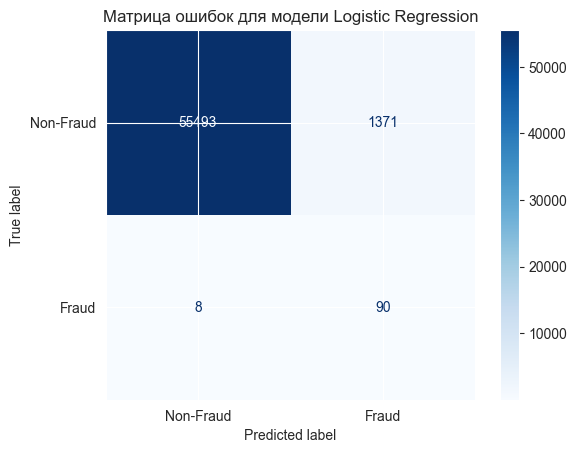


--- Коэффициенты для модели Logistic Regression (Logistic Regression) ---
               Feature  Coefficient
5        remainder__V4     0.921443
1   num_scaler__Amount     0.825811
23      remainder__V22     0.602663
29      remainder__V28     0.445728
6        remainder__V5     0.405913
2        remainder__V1     0.402664
12      remainder__V11     0.317884
22      remainder__V21     0.186667
3        remainder__V2     0.063334
20      remainder__V19     0.038436

Features with most negative coefficients:
             Feature  Coefficient
27    remainder__V26    -0.337347
0   num_scaler__Time    -0.365706
14    remainder__V13    -0.410455
9      remainder__V8    -0.471115
21    remainder__V20    -0.559016
18    remainder__V17    -0.605658
17    remainder__V16    -0.760113
13    remainder__V12    -0.767678
11    remainder__V10    -0.894750
15    remainder__V14    -1.132370

===== Настройка и обучение: Decision Tree =====
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Лу

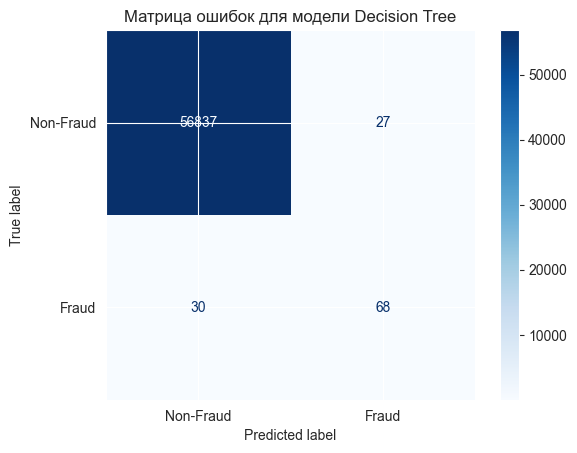


--- Важность признаков для модели Decision Tree ---
           Feature  Importance
15  remainder__V14    0.732875
5    remainder__V4    0.067405
13  remainder__V12    0.025502
14  remainder__V13    0.021932
9    remainder__V8    0.016462
19  remainder__V18    0.015162
21  remainder__V20    0.014462
16  remainder__V15    0.012230
11  remainder__V10    0.011879
8    remainder__V7    0.010971


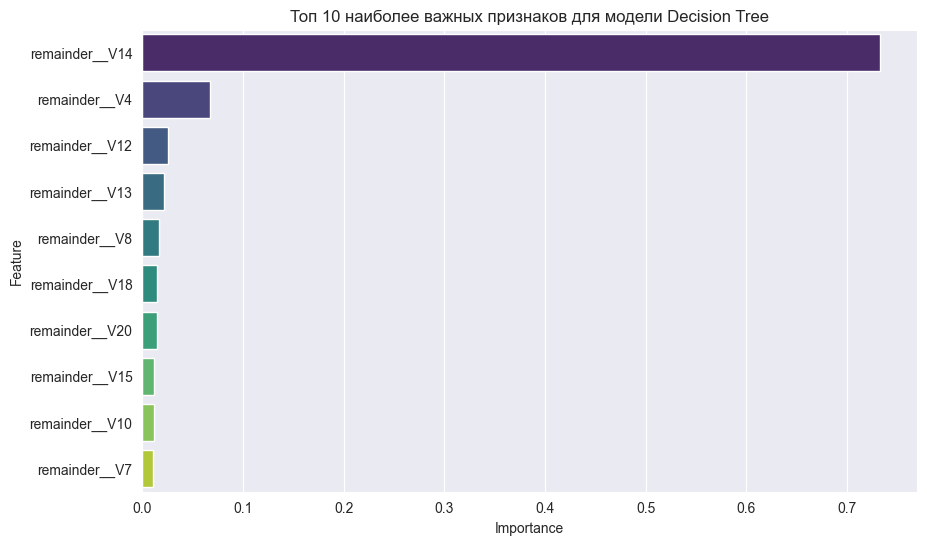


===== Настройка и обучение: Random Forest =====
Fitting 5 folds for each of 8 candidates, totalling 40 fits


KeyboardInterrupt: 

In [37]:
print("\n--- 4.2 Обучение, настройка и оценка каждой модели ---")

for model_name, model in models.items():
    print(f"\n===== Настройка и обучение: {model_name} =====")

    # Создайте полный конвейер: предварительная обработка -> классификатор
    # Это обеспечивает последовательное масштабирование в каждой итерации GridSearchCV.

    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('classifier', model)])

    # Выполните GridSearchCV для настройки гиперпараметров.
    # оценщик: Конвейер для настройки.
    # param_grid: Конкретная сетка гиперпараметров для текущей модели.
    # cv=skf: Используйте StratifiedKFold для перекрестной проверки, чтобы поддерживать баланс классов в каждой сворачивании.
    # scoring="f1": Оптимизируйте GridSearchCV на основе F1-оценки класса меньшинства, который подходит для дисбаланса.
    # n_jobs=-1: Используйте все доступные ядра процессора для более быстрых вычислений.
    # verbose=1: Печать сообщений о прогрессе.
    grid_search = GridSearchCV(full_pipeline, param_grids[model_name], cv=skf, scoring='f1', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train) # Подгонка GridSearchCV по обучающим данным

    # Храните лучшую модель и ее параметры
    best_model = grid_search.best_estimator_
    results[model_name] = {'Лучшая модель': best_model, 'Лучшие параметры': grid_search.best_params_}

    print(f"Лучшие параметры для {model_name}: {grid_search.best_params_}")

    # --- Оценим лучшую модель на тестовом наборе ---
    # Рассчитаем прогнозы на тестовом наборе
    y_pred = best_model.predict(X_test)
    # Получение вероятностных баллов для положительного класса (мошенничество) для расчета ROC AUC
    y_proba = best_model.predict_proba(X_test)[:, 1]

    # Рассчитаем и сохраним метрики эффективности
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    conf_matrix = confusion_matrix(y_test, y_pred)

    results[model_name].update({
        'Правильность': accuracy,
        'Точность': precision,
        'Полнота': recall,
        'f1_счётчик': f1,
        'roc_auc': roc_auc,
        'Матрица ошибок': conf_matrix
    })

    print(f"\nЭффективность для {model_name} на Тестовом наборе:")
    print(f"  Правильность (вводит в заблуждение из-за дисбаланса): {accuracy:.4f}")
    print(f"  Точность (класс мошенничества): {precision:.4f}")
    print(f"  Полнота (класс мошенничества): {recall:.4f}")
    print(f"  F1-счётчик (класс мошенничества): {f1:.4f}")
    print(f"  ROC AUC показатель: {roc_auc:.4f}")
    print("  Матрица ошибок:")
    
    # Визуализируйте матрицу несоответствий
    cmd_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Non-Fraud', 'Fraud'])
    cmd_display.plot(cmap='Blues', values_format='d') # 'd' for integer format
    plt.title(f'Матрица ошибок для модели {model_name}')
    plt.show()

    # --- 4.3 Важность признаков (для древовидных моделей) или Коэффициенты (для линейных моделей) ---
    # Извлечение важности признаков для древовидных моделей

    if hasattr(best_model.named_steps['classifier'], 'feature_importances_'):
        print(f"\n--- Важность признаков для модели {model_name} ---")
        feature_importances = best_model.named_steps['classifier'].feature_importances_

        # Получить имена функций с вывода препроцессора, чтобы правильно отобразить импорт
        # Это обрабатывает масштабированное «время», «сумма» и «Переход» V-Features
        preprocessed_feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

        # Создайте DataFrame для лучшей визуализации и сортировки
        importance_df = pd.DataFrame({
            'Feature': preprocessed_feature_names,
            'Importance': feature_importances
        }).sort_values(by='Importance', ascending=False)

        print(importance_df.head(10)) # Отобразим 10 наиболее важных признаков

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), hue='Feature', palette='viridis', legend=False)
        plt.title(f'Топ 10 наиболее важных признаков для модели {model_name}')
        plt.show()

    # Извлечём коэффициенты для линейных моделей (например, логистическая регрессия)
    elif hasattr(best_model.named_steps['classifier'], 'coef_'):
        print(f"\n--- Коэффициенты для модели {model_name} (Logistic Regression) ---")
        coefficients = best_model.named_steps['classifier'].coef_[0] # Для бинарной классификации, coef_ - 2d
        preprocessed_feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

        coef_df = pd.DataFrame({
            'Feature': preprocessed_feature_names,
            'Coefficient': coefficients
        }).sort_values(by='Coefficient', ascending=False)
        print(coef_df.head(10)) # Отобразим признаки с самыми большими положительными коэффициентами
        print("\nПризнаки с наиболее негативными коэффициентами:")
        print(coef_df.tail(10)) # Отобразим признаки с самыми большими отрицательными коэффициентами

In [ ]:
print("\n--- 5.1 Сравнительная сводка производительности моделей ---")

# Заведём датафрейм, чтобы суммировать результаты для исполнительного резюме
summary_data = []
for model_name, metrics in results.items():
    # Убедимся, что метрики доступны перед попыткой получить доступ к ним
    if 'accuracy' in metrics:
        summary_data.append({
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Precision (Fraud)': metrics['precision'],
            'Recall (Fraud)': metrics['recall'],
            'F1-Score (Fraud)': metrics['f1_score'],
            'ROC AUC': metrics['roc_auc']
        })

performance_summary_df = pd.DataFrame(summary_data).set_index('Model')
print(performance_summary_df.round(4))

# Определим лучшую модель на основе F1-показателя (поскольку она уравновешивает точность и отзыв)
best_f1_model_name = performance_summary_df['F1-Score (Fraud)'].idxmax()
print(f"\nЛучшая модель на F1-Score: **{best_f1_model_name}**")
